# Understanding and enriching Arabic seed domains

At Common Crawl, we want to improve the coverage of under-served languages in our data. One of the ways we do this is by asking for new seed domains from the languages, communities, and cultures we're interested in through our [web-languages project](https://github.com/commoncrawl/web-languages).

One of the languages for which we want better coverage is Arabic. Researchers from the [Qatar Computing Research Institute](https://www.hbku.edu.qa/en/qcri) shared a list of 30,000 Arabic domains with us, obtained from the Common Crawl corpus. These domains have been enriched with additional quality and content information: human annotators rated the quality of these domains by reviewing 20 random articles from each domain, and the researchers used GPT-4o to obtain the themes of five random articles in each domain as well as judgements about whether it should be kept based on the contents of the articles.

In this notebook, we use information in the Arabic seeds dataset to determine which domains should be added as seeds to the crawl, and what types of domains are present. We can then use these enriched seeds to help improve our coverage of Arabic content over the long term as we discover more related domains.

In [113]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import pycountry
import tldextract
import seaborn as sns

!tldextract --update

## Step one: data inspection and filtering

In [114]:
# read in the donated data and inspect columns
df = pd.read_excel("ArabicDomainQuality.xlsx")
df.head()

,id,domain,count,label,gpt_overall_label,gpt_labels,gpt_themes
0,231,ar.wikipedia.org,7845480,H,Accept,Med| Med| Med| Med| Med,Encyclopedia Entry - Sports| Encyclopedia Entr...
1,232,arabic.cnn.com,6764570,H,Accept,Med| High| High| High| High,News - Crime| News - Diplomacy| News - Middle ...
2,233,ar.m.wikipedia.org,6100580,H,Accept,High| High| High| High| High,Biography - Sports| Sports - Facilities| Histo...
3,234,arabic.euronews.com,5672929,H,Accept,High| High| High| High| High,News - European Politics| Health - Dietary Sup...
4,235,ar.tripadvisor.com,5115580,H,Accept,Med| Med| Med| Med| Med,Travel - Hotels and Resorts| Travel - Museums|...


The donated data contains seven columns:
- `id`: The original row ID.
- `domain`: The domain sourced from Common Crawl's corpus.
- `count`: The number of articles in the domain based on prior data from Common Crawl.
- `label`: Human annotation of the overall domain quality based on examining random 20 articles. Values can be H (high), M (medium), L (low, needs exhaustive cleaning, and less factual), or D (discard, e.g. pornography, gambling, etc.).
- `gpt_overall_label`: The majority label from `gpt_labels`.
- `gpt_labels`: Quality labels derived from GPT-4o for each of five random articles from the domain.
- `gpt_themes`: The themes of five random articles from the domain derived from GPT-4o.

### Understanding quality labels

The dataset contains both human labels (`label`) and LLM-generated judgements (`gpt_*`). Understanding the co-occurence is important to pick out any potential issues or surprises.

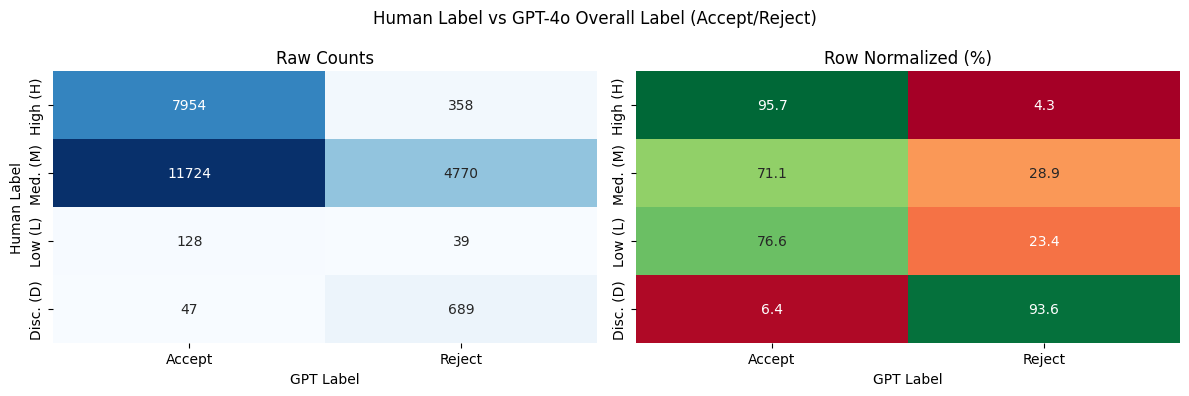

In [115]:
# heatmap of human labels versus GPT labels
label_order = ["H", "M", "L", "D"]
label_names = {"H": "High", "M": "Med.", "L": "Low", "D": "Disc."}

ct = (
    df.dropna(subset=["gpt_overall_label"])
    .pipe(lambda d: pd.crosstab(d["label"], d["gpt_overall_label"]))
    .reindex(label_order)
    .fillna(0)
)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

y_labels = [f"{label_names[l]} ({l})" for l in ct.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(
    ct, annot=True, fmt=".0f", cmap="Blues", yticklabels=y_labels, ax=ax1, cbar=False
)
ax1.set_title("Raw Counts")
ax1.set_xlabel("GPT Label")
ax1.set_ylabel("Human Label")

sns.heatmap(
    ct_pct,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    yticklabels=y_labels,
    ax=ax2,
    cbar=False,
)
ax2.set_title("Row Normalized (%)")
ax2.set_xlabel("GPT Label")
ax2.set_ylabel("")

fig.suptitle("Human Label vs GPT-4o Overall Label (Accept/Reject)")
plt.tight_layout()
plt.show()

The heatmaps show that on the extremes, humans and models usually agree: 95.7% of the domains rated as high quality by humans are judged acceptable by the LLM, and 93.6% of the domains marked to discard are rejected by the model as well. Interestingly, in the middle the LLM's judgement is less clear and a slightly greater proportion of domains rated as medium quality are discarded compared to those judged as low quality (28.9% versus 23.4%).

We'll now look at how the LLM-generated themes and human quality judgements interact.

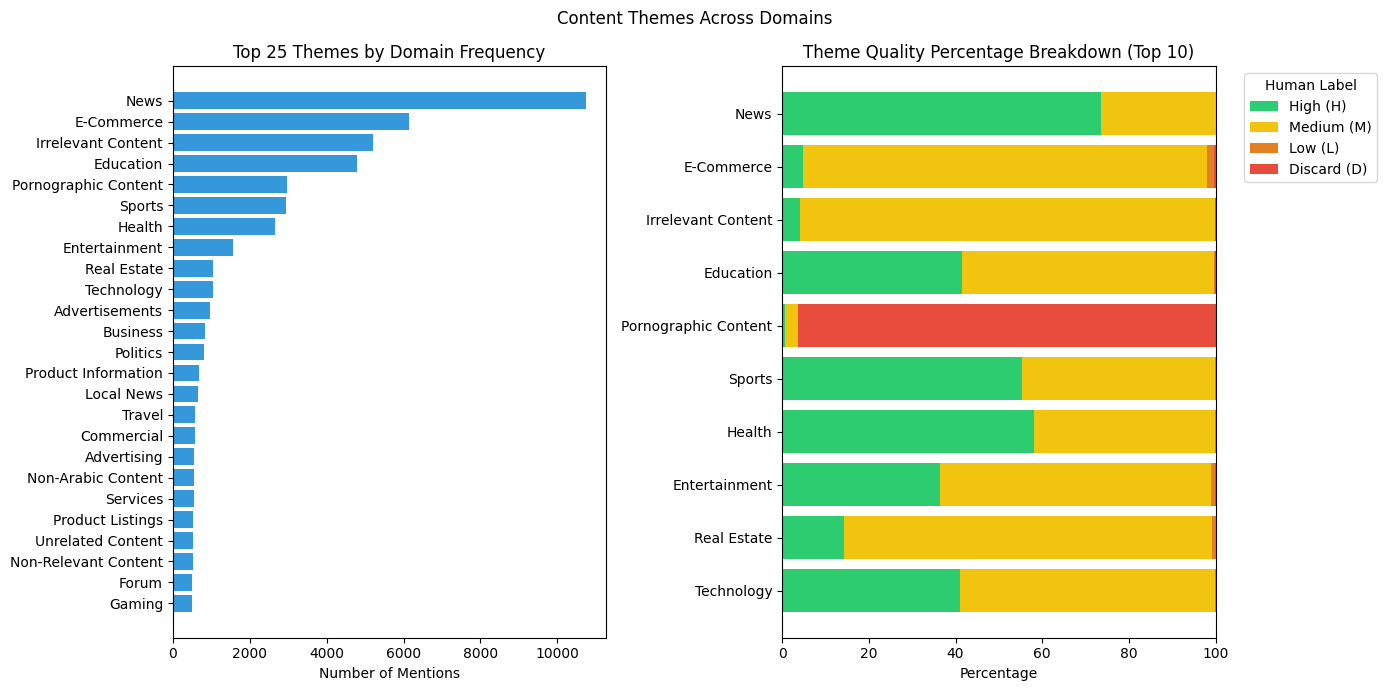

In [116]:
# plot topics by theme
label_order = ["H", "M", "L", "D"]
label_names = {"H": "High", "M": "Medium", "L": "Low", "D": "Discard"}
label_colors = {"H": "#2ecc71", "M": "#f1c40f", "L": "#e67e22", "D": "#e74c3c"}

theme_df = (
    df.dropna(subset=["gpt_themes"])[
        ["gpt_themes", "label", "count"]
    ]  # add 'count' here
    .assign(theme=df["gpt_themes"].str.split("|"))
    .explode("theme")
    .assign(theme=lambda d: d["theme"].str.split(" - ").str[0].str.strip().str.title())
    .reset_index(drop=True)
    .rename(
        columns={"count": "articles"}
    )  # rename to avoid confusion with pandas .count()
)

# Normalise theme names
replacements = {
    "Pornograph": "Pornographic Content",
    "Irrelevant": "Irrelevant Content",
}
for fragment, name in replacements.items():
    theme_df.loc[theme_df["theme"].str.contains(fragment), "theme"] = name
theme_df.loc[theme_df["theme"].str.startswith("Education"), "theme"] = "Education"

# Top 25 by frequency (reversed so highest appears at top of chart)
top25 = theme_df["theme"].value_counts().head(25).iloc[::-1]

# Row-normalised quality breakdown for the top 10
top10 = top25.index[-10:].tolist()
t10 = theme_df[theme_df["theme"].isin(top10)].reset_index(drop=True)
ct_pct = (
    pd.crosstab(t10["theme"], t10["label"])
    .reindex(index=top10, columns=label_order)
    .fillna(0)
    .pipe(lambda ct: ct.div(ct.sum(axis=1), axis=0) * 100)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

ax1.barh(top25.index, top25.values, color="#3498db")
ax1.set_xlabel("Number of Mentions")
ax1.set_title("Top 25 Themes by Domain Frequency")

left = pd.Series(0.0, index=ct_pct.index)
for label in label_order:
    ax2.barh(
        ct_pct.index,
        ct_pct[label],
        left=left,
        color=label_colors[label],
        label=f"{label_names[label]} ({label})",
    )
    left += ct_pct[label]

ax2.set_xlabel("Percentage")
ax2.set_title("Theme Quality Percentage Breakdown (Top 10)")
ax2.legend(title="Human Label", bbox_to_anchor=(1.05, 1), loc="upper left")

fig.suptitle("Content Themes Across Domains")
plt.tight_layout()
plt.show()

In [117]:
# show as treemap
theme_agg = (
    theme_df.groupby(["theme", "label"])
    .agg(count=("theme", "size"), total_articles=("articles", "sum"))
    .reset_index()
    .query("count >= 20")
)

fig = px.treemap(
    theme_agg,
    path=["theme", "label"],
    values="count",
    color="label",
    color_discrete_map=label_colors,
    title="Theme Treemap (size = number of domain mentions)",
    hover_data={"total_articles": ":,.0f"},
)
fig.update_layout(height=600)
fig.show()

The plots show that the LLM-generated themes which might be expected to contain lower-quality content (pornography, e-commerce, irrelevant content) mostly align with human opinions. This is encouraging for exploring these themes further.

Based on this analysis, we decided to only keep domains judged by humans as high or medium quality, as well as discarding all domains rejected by the model. 

In [118]:
# remove all domains marked Discard or Low by humans and Reject by GPT, or Discard for any one page
# also drop domains without GPT labels as these seemed to be unreachable
filtered = df[
    ~(
        df["label"].isin(["D", "L"])
        | (df["gpt_overall_label"] == "Reject")
        | (df["gpt_themes"].isna())
        | (df["gpt_labels"].str.contains("Discard"))
    )
].copy()
print(
    f"{len(df) - len(filtered)} domains were filtered out based on human and LLM quality judgements, or because they lack GPT labels."
)
print(f"{len(filtered)} domains remain ({len(filtered) / len(df):.1%}).")

10999 domains were filtered out based on human and LLM quality judgements, or because they lack GPT labels.
19001 domains remain (63.3%).


## Step two: adding location information

In many cases, the likely country associated with the domain can be derived from information in the domain itself. In this analysis, we use two kinds of information:
1) Country-code top level domains (ccTLDs) e.g. `.co.uk`, `.in`, `.fr`
2) Country or city words in the domain name (e.g. `www.jordan-hospital.com`)

### ccTLDs

In [119]:
# ccTLDs functions
extractor = tldextract.TLDExtract()


def extract_public_suffix(domain):
    """extracts the public suffix from a string URL"""
    result = extractor.extract_str(domain)
    return result.suffix


gtlds = {
    "com",
    "net",
    "org",
    "info",
    "shop",
    "online",
    "xyz",
    "biz",
    "store",
    "site",
    "top",
    "club",
    "edu",
}


def look_up_country_in_suffix(suffix):
    """Extract the likely country from the public suffix"""
    suffix_parts = suffix.split(".")
    end_suffix = suffix_parts[-1]  # country code always comes at end
    # label common gTLDs
    if len(suffix_parts) == 1 and suffix in gtlds:
        return "gTLD"
    # account for exceptions I found on Wikipedia
    if end_suffix == "uk":
        return "Great Britain"
    if end_suffix == "ac":
        return "Ascension Island"
    if end_suffix == "eu":
        return "European Union"
    if end_suffix == "co":
        return "gTLD"  # not strictly true (actually Colombia 🇨🇴)
    try:
        return pycountry.countries.lookup(end_suffix).name
    except LookupError:
        return "gTLD"

In [120]:
# get suffix information
filtered["suffix"] = filtered["domain"].apply(extract_public_suffix)
filtered["suffix_country"] = filtered["suffix"].apply(look_up_country_in_suffix)

In [121]:
# how many ccTLDs are there?
num_cctld = sum(filtered["suffix_country"] != "gTLD")
print(
    f"Extracted a country from {num_cctld:,} domains; {len(filtered) - num_cctld:,} ({(len(filtered) - num_cctld) / len(filtered):.1%}) have non-country TLDs."
)

Extracted a country from 2,917 domains; 16,084 (84.6%) have non-country TLDs.


In [122]:
filtered["suffix_country"].value_counts()[:25]

suffix_country
gTLD                         16084
Saudi Arabia                   368
United Arab Emirates           259
Morocco                        255
Egypt                          163
Palestine, State of            143
Iraq                           112
Montenegro                     108
Tunisia                        107
Poland                          98
Algeria                         91
Jordan                          83
Tuvalu                          81
Libya                           74
France                          69
Qatar                           68
Syrian Arab Republic            57
Netherlands                     55
Lebanon                         52
Kuwait                          48
Iran, Islamic Republic of       44
Belgium                         42
Germany                         41
Cocos (Keeling) Islands         37
Oman                            34
Name: count, dtype: int64

### Country information in domain name

In [123]:
# functions to look for country information in text of domain
countries = {x.name.lower(): x.name for x in list(pycountry.countries)}
# this lookup of local information could be extended with more domain knowledge
local_names = {
    "misr": "Egypt",
    "masr": "Egypt",
    "msr": "Egypt",
    "tunis": "Tunisia",
    "saudi": "Saudi Arabia",
    "maroc": "Morocco",
    "emirat": "United Arab Emirates",
    "abudhabi": "United Arab Emirates",
    "dhabi": "United Arab Emirates",
    "dubai": "United Arab Emirates",
    "ajman": "United Arab Emirates",
    "sharjah": "United Arab Emirates",
    "khaimah": "United Arab Emirates",
    "quwain": "United Arab Emirates",
    "fujairah": "United Arab Emirates",
    "cairo": "Egypt",
    "baghdad": "Iraq",
    "riyadh": "Saudi Arabia",
    "jeddah": "Saudi Arabia",
    "sanaa": "Yemen",
    "damascus": "Syria",
    "amman": "Jordan",
    "manama": "Bahrain",
    "doha": "Qatar",
    "khartoum": "Sudan",
    "muscat": "Oman",
    "ksa": "Saudi Arabia",
    "lebanese": "Lebanon",
    "arz": "Egypt",
    "uae": "United Arab Emirates",
    "ary": "Morocco",
}

trans = str.maketrans("._", "--")  # convert dots and underscores into dashes


def find_country_info_in_domain(website: str):
    """Infer the originating country of a domain based on geographic lookups"""
    # look at local names first as these are more specific
    for key in local_names:
        if key in website:
            return local_names[key]
    # check against other countries
    for key in countries:
        if key in website:
            return countries[key]
    # finally check segments for country codes
    parts = website.translate(trans).split("-")
    for p in parts:
        if len(p) == 2:
            if p in {
                "ar",
                "as",
                "al",
                "co",
            }:  # misleading special cases, mostly mean "the" in Arabic
                return None
            try:
                return pycountry.countries.lookup(p).name
            except LookupError:
                return None

In [124]:
# enrich with country information from text of domain, then combine both predictions to infer a country
filtered["domain_country"] = filtered["domain"].apply(find_country_info_in_domain)
# country derived from the suffix has more weight in the inferred country
filtered["inferred_country"] = (
    filtered["suffix_country"]
    .where(filtered["suffix_country"] != "gTLD", filtered["domain_country"])
    .fillna("None")
)

In [125]:
# how many domains now have an inferred country?
num_with_country = len(filtered) - sum(filtered["inferred_country"] == "None")
print(
    f"{num_with_country:,} entries have an inferred country ({num_with_country / len(filtered):.1%} of the total)."
)

4,858 entries have an inferred country (25.6% of the total).


In [126]:
# let's look at some examples of the inferred countries
filtered[filtered["inferred_country"] != "None"].sample(n=5)

,id,domain,count,label,gpt_overall_label,gpt_labels,gpt_themes,suffix,suffix_country,domain_country,inferred_country
24715,19246,www.alassad-library.gov.sy,27541,H,Accept,High| High| High| High| High,Cultural Events and Activities| Library Servic...,gov.sy,Syrian Arab Republic,Morocco,Syrian Arab Republic
8105,30636,kzhs.pl,70713,M,Accept,Med| Med| Med| Med| Med,Construction - Machinery and Equipment| Constr...,pl,Poland,Poland,Poland
743,974,cairo-times.com,320044,H,Accept,Med| Med| Med| Med| Med,Trending News - Crime| Health - Celebrity News...,com,gTLD,Egypt,Egypt
2389,23920,libyaschannel.com,158701,H,Accept,High| Med| High| High| High,Legal News - Fuel Smuggling Case| Technology -...,com,gTLD,Libya,Libya
21906,16437,cm-to-m.appspot.com,31335,H,Accept,Med| Med| Med| Med| Med,Unit Conversion - Length| Unit Conversion - Le...,com,gTLD,Cameroon,Cameroon


In [127]:
# what are the most common inferred countries?
filtered["inferred_country"].value_counts()[:25]

inferred_country
None                    14143
Saudi Arabia              676
Egypt                     548
United Arab Emirates      487
Morocco                   364
Iraq                      214
Tunisia                   146
Palestine, State of       145
Kuwait                    140
Montenegro                130
Algeria                   128
Jordan                    124
Tuvalu                    109
Lebanon                   103
Qatar                     102
Yemen                     101
Poland                     99
Libya                      96
Syrian Arab Republic       89
France                     73
Oman                       67
Bahrain                    59
Sudan                      59
Netherlands                55
Germany                    46
Name: count, dtype: int64

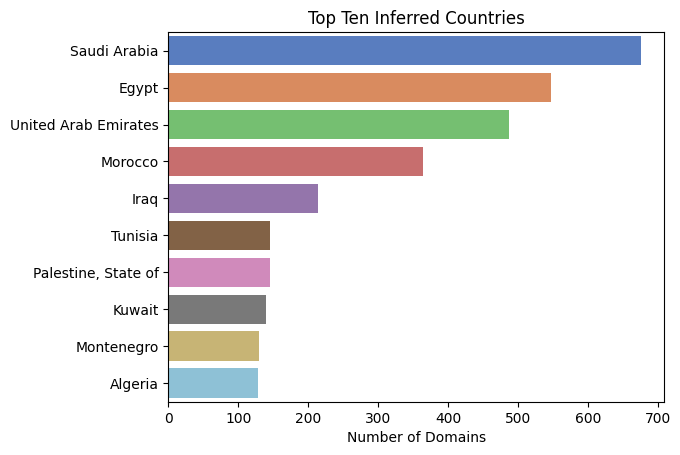

In [128]:
# plot the top ten inferred countries
top_countries = (
    filtered[filtered["inferred_country"] != "None"]["inferred_country"]
    .value_counts()
    .head(10)
)
ax = sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette="muted",
    hue=top_countries.index,
    legend=False,
)
ax.set(title="Top Ten Inferred Countries", ylabel=None, xlabel="Number of Domains")

plt.show()

Most of the inferred countries are from the Arabic-speaking world, which is promising. Some of the surprises are explained by looking at their ccTLDs: Montenegro (`.me`), Poland (`.pl` - used for Palestine as well?), and Tuvalu (`.tv`). Other countries have historical links with the Arabic speaking world (France, Germany, the Netherlands). Whilst the inferred country isn't perfect, it looks good enough to be useful.

## Step three: enrich with domain categories

We will now use the GPT-derived themes for the random pages on each website to categorise the domains. We're especially interested in news and government sites.

In [129]:
# what do the theme strings look like?
for t in filtered["gpt_themes"].sample(5).values:
    print(t)

Telecommunications - Promotions| Telecommunications - Offers| Telecommunications - Service Details| Telecommunications - Customer Support| Telecommunications - Internet Services
E-commerce - Electronics| E-commerce - Electronics| E-commerce - Accessories| E-commerce - Accessories| E-commerce - Accessories
Organic Products - Sales| Organic Products - Sales| Organic Products - Sales| Organic Products - Sales| Organic Products - Sales
Religious - Islamic Teachings| Religious - Quran and Interpretation| Religious - Historical Figures in Islam| Religious - Teachings on the Ahlulbayt| Religious - Prayers and Supplications
Quran Analysis and Statistics| Quran Analysis and Statistics| Quran Analysis and Statistics| Quran Analysis and Statistics| Quran Analysis and Statistics


For each domain, the five random pages' themes are given in a pipe-separated list. Since each theme is from a random page in the domain, a particular theme may not be representative of the website as a whole. However, if multiple pages have similar themes, it's likely that these represent the domain as a whole. 

In [130]:
def extract_top_theme(theme_string):
    """extract the likely top theme for each domain based on most common themes in page summaries"""
    # split into individual summaries and remove subcategories (after " - ")
    themes = [
        x.split(" - ")[0].lower().replace(" and ", " ").strip()
        for x in theme_string.split("|")
    ]
    twograms = [list(zip(x.split(" "), x.split(" ")[1:])) for x in themes]
    # want longest n-grams first in case of ties with counter, likely more informative
    twograms = sorted(
        [" ".join(pair) for item in twograms for pair in item], key=len, reverse=True
    )
    onegrams = sorted(
        [i for line in themes for i in line.split(" ")], key=len, reverse=True
    )
    grams = twograms + onegrams
    c = Counter(grams)

    return c.most_common(1)[0][0]  # to get just theme

In [131]:
filtered.sample(5)

,id,domain,count,label,gpt_overall_label,gpt_labels,gpt_themes,suffix,suffix_country,domain_country,inferred_country
25602,20133,ar.junuotvbox.com,26404,M,Accept,Med| Med| Med| Med| Med,Product Information - TV Boxes| Product Review...,com,gTLD,NaN,None
4514,27045,www.iptvtunisie.com,105840,M,Accept,Med| Med| Med| Med| Med,Sports - Football| Employment - Job Offers| Te...,com,gTLD,Tunisia,Tunisia
11227,3458,www.super-saudi.com,55700,M,Accept,Med| Med| Med| Med| Med,Cleaning Services| Car Detailing Services| Ins...,com,gTLD,Saudi Arabia,Saudi Arabia
16011,9542,honapal.com,42020,M,Accept,Med| Med| Med| Med| Med,Horoscopes| Economy - Gold Prices| Economy - G...,com,gTLD,NaN,None
565,796,www.almadenahnews.com,365409,H,Accept,High| High| High| Med| Med,News - International Affairs| News - Legal and...,com,gTLD,NaN,None


In [132]:
# what do we get for top themes?
filtered["top_theme"] = filtered["gpt_themes"].apply(extract_top_theme)
filtered["top_theme"].value_counts()[:25]

top_theme
news                     2376
e-commerce               1188
sports                    550
health                    546
education                 415
entertainment             336
educational               266
services                  255
real estate               235
technology                226
islamic                   210
politics                  203
political                 184
advertisements            175
business                  167
religious                 158
cultural                  118
local news                116
educational resources     113
university                111
advertising               110
product information       110
travel                    109
forum                     105
tech                       98
Name: count, dtype: int64

In [133]:
filtered[["gpt_themes", "top_theme"]].sample(5)

,gpt_themes,top_theme
10876,Literary Reflections| Java Programming Concept...,java programming
23581,Biography - Public Figures| Biography - Sports...,biography
553,E-commerce - Video Game Accessories| E-commerc...,e-commerce
14618,Real Estate Listings| Real Estate Listings| Re...,estate listings
18634,Marketing - Book Review| Marketing - Distribut...,marketing


These themes look reasonable. We will use them, along with other information in the domain, to enrich the list of websites. We'll add information in order of interest to make sure the most interesting categories to us are as big as possible: government and news first, then other popular categories. The categorisation here assumes that each website can only belong to one category: this is good enough given our focus on finding seeds for the crawl.

In [134]:
# government and news first
filtered["category"] = np.where(
    filtered["suffix"].str.contains("gov"), "Government", "Other"
)
filtered.loc[filtered["top_theme"].str.contains("news", na=False), "category"] = "News"
filtered.loc[filtered["domain"].str.contains("news", na=False), "category"] = "News"

filtered["category"].value_counts()

category
Other         15582
News           3170
Government      249
Name: count, dtype: int64

In [135]:
# other common themes: sports, religion, education, politics, commerce
filtered.loc[
    (filtered["category"] == "Other")
    & (filtered["top_theme"].str.contains("sport", na=False)),
    "category",
] = "Sport"

filtered.loc[
    (filtered["category"] == "Other")
    & (filtered["suffix"].str.contains("edu", na=False)),
    "category",
] = "Education"

filtered.loc[
    (filtered["category"] == "Other")
    & (filtered["top_theme"].str.contains("relig|islam|chris|buddis", na=False)),
    "category",
] = "Religious"

filtered.loc[
    (filtered["category"] == "Other")
    & (filtered["top_theme"].str.contains("educat|academ", na=False)),
    "category",
] = "Education"

filtered.loc[
    (filtered["category"] == "Other")
    & (filtered["top_theme"].str.contains("politic", na=False)),
    "category",
] = "Politics"

filtered.loc[
    (filtered["category"] == "Other")
    & (
        filtered["top_theme"].str.contains(
            "commerc|estate|advert|business|product|job|shop|classified|trading|marketing",
            na=False,
        )
    ),
    "category",
] = "Commerce"

In [136]:
# how many sites for each category?
print(
    f"{sum(filtered['category'] == 'Other') / len(filtered):.1%} of domains are categorised as 'Other'."
)
top_cats = filtered["category"].value_counts()
top_cats

49.1% of domains are categorised as 'Other'.


category
Other         9333
Commerce      3301
News          3170
Education     1255
Religious      726
Sport          533
Politics       434
Government     249
Name: count, dtype: int64

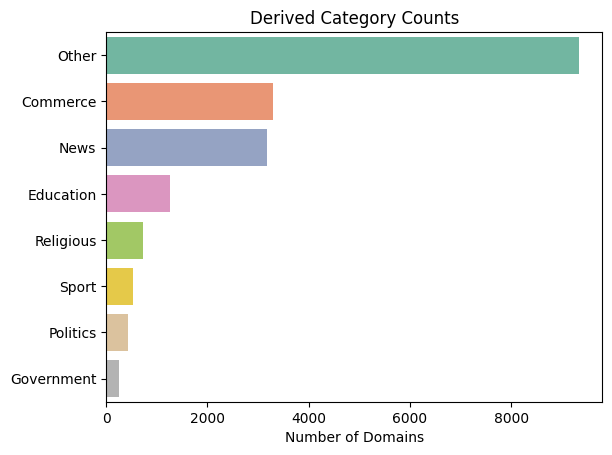

In [137]:
# plot categories
ax = sns.barplot(
    x=top_cats.values,
    y=top_cats.index,
    palette="Set2",
    hue=top_cats.index,
    legend=False,
)
ax.set(title="Derived Category Counts", ylabel=None, xlabel="Number of Domains")

plt.show()

In [138]:
# what top themes are not captured in categories?
filtered[filtered["category"] == "Other"]["top_theme"].value_counts()[:20]

top_theme
health                  512
entertainment           299
services                247
technology              215
cultural                107
travel                  106
forum                   105
tech                     97
books                    92
literature               89
gaming                   88
dream interpretation     71
legal                    69
information              69
human rights             68
tv series                65
finance                  64
fashion                  59
software                 59
research                 58
Name: count, dtype: int64

From inspection, the remaining top themes contain a more diverse and noisier selection of domains, and are of less interest to us as a category of domains to crawl.

In [139]:
# tidy up and add reversed host name (more useful for sorting and searching)
def reverse_domain(domain):
    """Reverses the domain name from a string URL"""
    result = extractor.extract_str(domain)
    return result.reverse_domain_name


filtered["reversed_domain"] = filtered["domain"].apply(reverse_domain)
enriched = filtered[
    [
        "reversed_domain",
        "suffix",
        "domain",
        "inferred_country",
        "label",
        "gpt_overall_label",
        "gpt_labels",
        "category",
        "top_theme",
        "gpt_themes",
    ]
]
enriched.sample(3)

,reversed_domain,suffix,domain,inferred_country,label,gpt_overall_label,gpt_labels,category,top_theme,gpt_themes
21737,com.starwood-eg,com,starwood-eg.com,Egypt,M,Accept,Med| Med| Med| Med| Med,Commerce,furniture products,Furniture Products - Catalog| Furniture Produc...
26808,com.dramalinet.www,com,www.dramalinet.com,Mali,H,Accept,Med| Med| Med| Med| Med,Other,tutorials on,Tutorials on using apps| Tutorials on using ap...
556,com.muhtwa.www,com,www.muhtwa.com,None,H,Accept,Med| Med| High| Med| Med,Other,dream interpretation,Dream Interpretation| Month Overview| Medical ...


## Step four: check crawl for language information

Domains on the web are not static, but rather their content and owners are likely to change over time. Since we want to prioritise Arabic content with these seeds, we will check that for the domains we can find in our most recent crawls, their content is still in Arabic.

We use [AWS Athena](https://aws.amazon.com/athena/) to query the [URL index](https://commoncrawl.org/url-index) to carry out this analysis. First, we upload a TSV of the reversed domains to S3, and add it as a table:

```sql
CREATE EXTERNAL TABLE arabic_seeds (
    reversed_host STRING)
    LOCATION 's3://<bucket_name>/arabic_seeds/';
```

Next, we query the most recent crawl to bring back the language predictions for each captured page in each domain, if it's found in the most recent crawl (`CC-MAIN-2026-21`):

```sql
SELECT 
    s.reversed_host,
    c.language_counts
FROM "ccindex"."arabic_seeds" s
LEFT JOIN (
    SELECT 
        url_host_name_reversed,
        histogram(language) as language_counts
    FROM "ccindex"."ccindex",
    UNNEST(split(content_languages, ',')) AS t (language)
    WHERE crawl = 'CC-MAIN-2026-21'
        AND subset = 'warc'
    GROUP BY url_host_name_reversed
) c ON s.reversed_host = c.url_host_name_reversed
```

This query brings back the language predictions for all the pages for the seed domains found in the crawl. It then groups by the domain again, counting how many times each language prediction appears for all the pages across the domain. This count is rough, since a page can have multiple language predictions, but it indicates if there is likely Arabic content in the domain.

For the domains we don't find in the most recent crawl, we search the next most recent crawl (`CC-MAIN-2026-17`), and then the next for any still without matches (`CC-MAIN-2026-12`). We filter out any pages we find where the language predictions do not contain Arabic.


In [140]:
# join the language enrichment from the crawl with the existing dataframe
lang_df = pd.read_csv(
    "crawl_lang_info.tsv", sep="\t", names=["reversed_domain", "detected_langs"]
)
lang_df = lang_df.sort_values(by=["reversed_domain", "detected_langs"]).drop_duplicates(
    keep="first", subset="reversed_domain"
)  # will keep detected_langs over NaN
with_langs = pd.merge(enriched, lang_df, how="left", on="reversed_domain")
print(
    f"{sum(~with_langs['detected_langs'].isna()):,} domains were enriched with language information ({sum(~with_langs['detected_langs'].isna()) / len(with_langs):.1%})."
)

8,772 pages were enriched with language information (46.2%).


In [141]:
# filter out pages where language info was found, but it doesn't contain arabic
with_langs = with_langs[
    (with_langs["detected_langs"].str.contains("ara"))
    | (with_langs["detected_langs"].isna())
]

print(
    f"{len(enriched) - len(with_langs)} domains are removed as retrieved domains do not contain detected Arabic and are filtered out."
)
print(
    f"{len(with_langs) - sum(with_langs['detected_langs'].isna())} of the remaining {len(with_langs):,} domains have language information from the crawl ({(len(with_langs) - sum(with_langs['detected_langs'].isna())) / len(with_langs):.1%})."
)

801 domains are removed as retrieved domains do not contain detected Arabic and are filtered out.
7971 of the remaining 18,200 domains have language information from the crawl (43.8%).


In [142]:
with_langs.sample(5)

,reversed_domain,suffix,domain,inferred_country,label,gpt_overall_label,gpt_labels,category,top_theme,gpt_themes,detected_langs
12594,net.amrecancenter.www,net,www.amrecancenter.net,None,M,Accept,Med| Med| Med| Med| Med,Other,automotive services,Automotive Services - Nissan Repair| Automotiv...,"{ara=685, eng=1}"
8903,com.zdarab.www,com,www.zdarab.com,None,H,Accept,Med| Med| Med| Med| Med,News,news,Celebrity News| Storytelling| Entertainment Ne...,NaN
13221,com.a-onec.bac,com,bac.a-onec.com,None,M,Accept,High| High| High| High| High,Education,education,Education - Baccalaureate Information| Educati...,"{ara=383, por=6, fra=3, xho=14, nno=1, eng=54}"
11151,com.rotana.ar,com,ar.rotana.com,None,M,Accept,Med| Med| Med| Med| Med,Other,hospitality,Hospitality - Dining and Accommodation| Hospit...,"{tur=1, ara=131, fra=1, sun=1, eng=76}"
403,net.alarab.mp31,net,mp31.alarab.net,None,M,Accept,Med| Med| Med| Med| Med,Other,music,Music - General| Music - General| Music - Gene...,NaN


## Wrap up

In this notebook, we've walked through filtering and enriching a long list of Arabic domains to understand the categories of information they contain and which ones might be added to the crawl. We'd like to understand more about these domains - if you want to check the accuracy of our categories or add further insights, please reach out!

In [34]:
# export as tsv
with_langs.sort_values(by="reversed_domain").to_csv(
    "enriched_arabic_seeds.tsv", sep="\t", index=False
)